# Hourly Sales Analysis — OC217 Drumcondra (7–13 April 2025)

This notebook walks through an exploratory analysis of one week of hourly sales data exported from the POS system.

**What the source file is:** a pivot-table export — one row per opening hour (07:00–18:00), one pair of columns (Customer Count, Net Sale) per day, for a single store.

**Goal:** understand when the store is busiest, when it earns the most, and whether those two things line up. 

**Structure of this notebook:**
1. Load & inspect the raw file
2. Reshape into a tidy (long-format) table
3. Data quality checks
4. Descriptive statistics
5. Visualisations (heatmap, daily trend, hourly trend, average spent-per-customer)
6. Summary of findings

### 1. Import Libraries

- Pandas - data exploration and manipulation library. 
- Numpy - Numerical Python. Compute mathematics efficiently. 
- Seaborn/Matplotlib - built on top of Matplotlib. It is a data visualisation library. 

In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore') # We can suppress the warnings

In [4]:
sns.set_theme(style="whitegrid")
pd.set_option('display.width', 120)

### 2. Load the raw file

The export has a few metadata rows at the top (print date, store name, date range) before the real table starts. The real header spans two rows:

- Row 1 of the header: the date (one date repeated across a "Customer Count" column and a "Net Sale" column)

- Row 2 of the header: which of the two metrics each column is

Rather than manually skipping rows and renaming columns, we tell pandas directly which two rows form the header (header=[6, 7], 0-indexed) and which column is the index (index_col=0, the hour). Pandas then builds a MultiIndex — a two-level column label — automatically, and forward-fills the merged date cells for us. 

In [6]:
FILE = "Hourly_Sales_7thApri_13thapr.xlsx"  # keep this notebook in the same folder as the file

raw = pd.read_excel('Hourly_Sales_7thApri_13thapr.xlsx', header=[6, 7], index_col=0)
raw.index.name = "Hour"
raw.head(15)

07/04/2025                  08/04/2025                  09/04/2025                  10/04/2025  \
            Customer Count     Net Sale Customer Count     Net Sale Customer Count     Net Sale Customer Count   
Hour                                                                                                             
07                       9    37.797356             12    60.754985             22   114.058950              9   
08                      27   128.743316             36   197.514493             33   147.935777             34   
09                      35   138.682733             39   199.554813             35   153.261517             31   
10                      34   192.682295             28   172.329296             28   162.266926             34   
11                      30   150.765857             35   161.057264             25   138.615815             28   
12                      32   220.636816             35   209.809092             21   119.663585             37   
13                      37   219.388242             38   208.258912             28   170.784706             24   
14                      39   166.281918             22   161.128543             24   148.138022             29   
15                      15    78.339419             28   153.711306             31   174.544428             24   
16                      25   142.148969             29   138.714047             28   159.351551             26   
17                      15    70.155338             13    71.476663             13    58.792482             20   
18                      11    53.876649              9    36.343611              4    13.920705              8   
Grand Total            309  1599.498908            324  1770.653025            292  1561.334464            304   

                             11/04/2025                  12/04/2025                  13/04/2025               \
                Net Sale Customer Count     Net Sale Customer Count     Net Sale Customer Count     Net Sale   
Hour                                                                                                           
07             50.660793              9    57.579953            NaN          NaN            NaN          NaN   
08            194.675684             57   281.270595           19.0   117.734678           10.0    49.030835   
09            150.881053             33   170.347937           35.0   298.167261           28.0   165.291890   
10            222.304544             38   238.880100           43.0   314.595148           27.0   167.835674   
11            157.967301             35   161.416674           31.0   250.076286           42.0   300.455689   
12            244.262536             33   301.360599           22.0   139.735685           27.0   180.493604   
13            140.245673             39   277.909604           24.0   152.536258           29.0   182.748549   
14            263.964551             23   137.472150           19.0   119.965007           26.0   160.671393   
15            136.418626             13    83.030057           16.0   179.016165           18.0   140.830554   
16            126.630646             28   140.505754           27.0   144.730848           31.0   170.833246   
17            108.979618             27   142.055983           20.0    96.533072           10.0    40.910784   
18             49.162993             21   102.069585            3.0    13.045735            2.0     2.276423   
Grand Total  1846.154018            356  2093.898991          259.0  1826.136143          250.0  1561.378641   

               Grand Total                
            Customer Count      Net Sale  
Hour                                      
07                      61    320.852037  
08                     216   1116.905378  
09                     236   1276.187204  
10                     232   1470.893983  
11                     226   1320.354886  
12                     207   1415.961917  
13         

### Two things to drop before analysis:
- The **`Grand Total`** row (bottom) — a pre-computed total, not an observation
- The **`Grand Total`** column pair (right-hand side) — same reason, a summary, not a data point

We keep the raw totals available separately in case we want to sanity-check our own aggregations against them later.

In [8]:
grand_total_row = raw.loc["Grand Total"]
grand_total_col = raw["Grand Total"]

df = raw.drop(index="Grand Total").drop(columns="Grand Total")
df.index = df.index.astype(int)   # hour as integer, not text
df.head()

07/04/2025                 08/04/2025                 09/04/2025                 10/04/2025              \
     Customer Count    Net Sale Customer Count    Net Sale Customer Count    Net Sale Customer Count    Net Sale   
Hour                                                                                                               
7                 9   37.797356             12   60.754985             22  114.058950              9   50.660793   
8                27  128.743316             36  197.514493             33  147.935777             34  194.675684   
9                35  138.682733             39  199.554813             35  153.261517             31  150.881053   
10               34  192.682295             28  172.329296             28  162.266926             34  222.304544   
11               30  150.765857             35  161.057264             25  138.615815             28  157.967301   

         11/04/2025                 12/04/2025                 13/04/2025              
     Customer Count    Net Sale Customer Count    Net Sale Customer Count    Net Sale  
Hour                                                                                   
7                 9   57.579953            NaN         NaN            NaN         NaN  
8                57  281.270595           19.0  117.734678           10.0   49.030835  
9                33  170.347937           35.0  298.167261           28.0  165.291890  
10               38  238.880100           43.0  314.595148           27.0  167.835674  
11               35  161.416674           31.0  250.076286           42.0  300.455689

## 3. Reshape into tidy (long) format

Right now the table is **wide**: one row per hour, with 7 days x 2 metrics spread across columns. That's fine for reading, but awkward for plotting and grouping.

We convert it to **tidy/long format** — one row per (Hour, Date, Metric) combination — using `stack()`. Tidy data is the standard shape for both `seaborn` and most statistical/ML tooling: each row is a single observation, each column a single variable.

In [10]:
long = (
    df.stack(level=0, future_stack=True)          # bring the date level down into rows
      .rename_axis(index=["Hour", "Date"])
      .reset_index()
)
long["Date"] = pd.to_datetime(long["Date"], format="%d/%m/%Y")
long["DayOfWeek"] = long["Date"].dt.day_name()

long.head(10)


,Hour,Date,Customer Count,Net Sale,DayOfWeek
0,7,2025-04-07,9.0,37.797356,Monday
1,7,2025-04-08,12.0,60.754985,Tuesday
2,7,2025-04-09,22.0,114.058950,Wednesday
3,7,2025-04-10,9.0,50.660793,Thursday
4,7,2025-04-11,9.0,57.579953,Friday
5,7,2025-04-12,NaN,NaN,Saturday
6,7,2025-04-13,NaN,NaN,Sunday
7,8,2025-04-07,27.0,128.743316,Monday
8,8,2025-04-08,36.0,197.514493,Tuesday
9,8,2025-04-09,33.0,147.935777,Wednesday


## 4. Data quality checks

- **Missing values** — There are some hours which have no data on some days, for example Saturday and Sunday because the store opens later at the weekends and bank holidays. 
- **Data types** — are Customer Count and Net Sale numeric, not text?
- **Internal consistency** — do our own day totals match the file's own `Grand Total` row, as a sanity check that the reshape didn't lose or duplicate anything?

In [12]:
print("Missing values per column:")
print(long.isna().sum())
print()
print("Data types:")
print(long.dtypes)

Missing values per column:
Hour              0
Date              0
Customer Count    2
Net Sale          2
DayOfWeek         0
dtype: int64

Data types:
Hour                       int32
Date              datetime64[ns]
Customer Count           float64
Net Sale                 float64
DayOfWeek                 object
dtype: object


In [13]:
# Which (Hour, Date) combinations are missing Net Sale?
missing = long[long["Net Sale"].isna()]
missing[["Hour", "Date", "DayOfWeek"]]


,Hour,Date,DayOfWeek
5,7,2025-04-12,Saturday
6,7,2025-04-13,Sunday


These missing hours are almost certainly **the store not opening that hour**, not a data error. We'll leave them as `NaN` (not zero) so they don't distort hourly averages for days when the store *was* open at that hour.

In [15]:
# Sanity check: do our reshaped daily totals match the file's own Grand Total row?
check = (
    long.groupby("Date")[["Customer Count", "Net Sale"]].sum().round(2)
)
file_totals = grand_total_row.drop("Grand Total", level=0).xs("Net Sale", level=1)
check["Net Sale (file total)"] = file_totals.values.round(2)
check["Match"] = np.isclose(check["Net Sale"], check["Net Sale (file total)"])
check

,Customer Count,Net Sale,Net Sale (file total),Match
Date,,,,
2025-04-07,309.0,1599.50,1599.50,True
2025-04-08,324.0,1770.65,1770.65,True
2025-04-09,292.0,1561.33,1561.33,True
2025-04-10,304.0,1846.15,1846.15,True
2025-04-11,356.0,2093.90,2093.90,True
2025-04-12,259.0,1826.14,1826.14,True
2025-04-13,250.0,1561.38,1561.38,True


## 5. Descriptive statistics

A quick numeric summary before any charts — this is often enough to catch outliers or surprises.

In [17]:
long[["Customer Count", "Net Sale"]].describe().round(2)

,Customer Count,Net Sale
count,82.00,82.00
mean,25.54,149.50
std,10.47,70.41
min,2.00,2.28
25%,19.25,114.98
50%,27.00,150.82
75%,33.00,180.12
max,57.00,314.60


### 6. Derived metric: average spend per customer
Customer Count and Net Sale each tell only half the story — a busy hour isn't necessarily a profitable one. Dividing the two gives average net sale per customer, which separates "busy" from "high-value." It was created a new column within the dataset called "Avg Spend per Customer"


In [19]:
long["Avg Spend per Customer"] = long["Net Sale"] / long["Customer Count"]
long[["Hour", "Date", "DayOfWeek", "Customer Count", "Net Sale", "Avg Spend per Customer"]].head(15)

,Hour,Date,DayOfWeek,Customer Count,Net Sale,Avg Spend per Customer
0,7,2025-04-07,Monday,9.0,37.797356,4.199706
1,7,2025-04-08,Tuesday,12.0,60.754985,5.062915
2,7,2025-04-09,Wednesday,22.0,114.058950,5.184498
3,7,2025-04-10,Thursday,9.0,50.660793,5.628977
4,7,2025-04-11,Friday,9.0,57.579953,6.397773
5,7,2025-04-12,Saturday,NaN,NaN,NaN
6,7,2025-04-13,Sunday,NaN,NaN,NaN
7,8,2025-04-07,Monday,27.0,128.743316,4.768271
8,8,2025-04-08,Tuesday,36.0,197.514493,5.486514
9,8,2025-04-09,Wednesday,33.0,147.935777,4.482902


## 7. Visualisations

### 7.1 Heatmap — Net Sale by Hour x Day

The fastest way to see the whole week's rhythm at once. Darker/brighter cells = higher sales. 

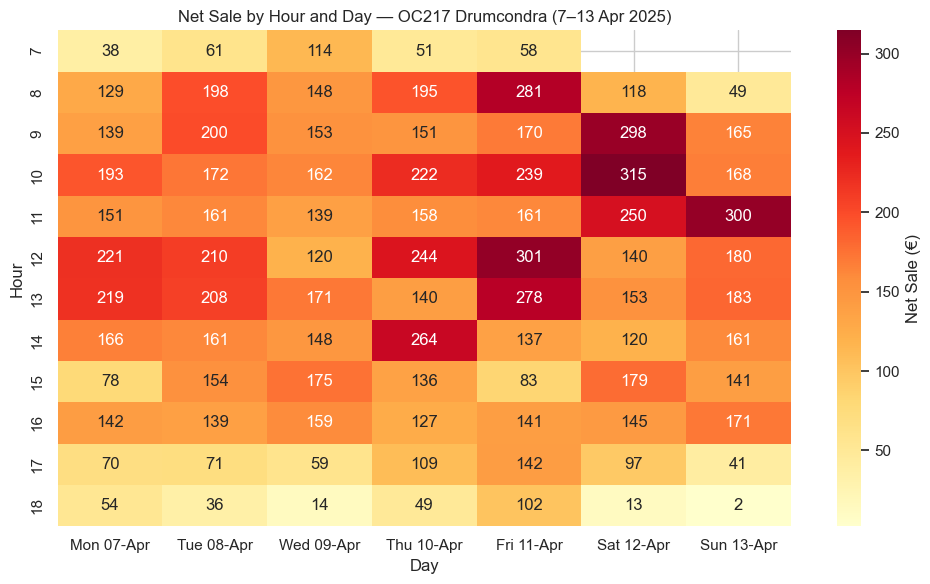

In [21]:
pivot_sales = long.pivot(index="Hour", columns="Date", values="Net Sale") #reshaping the data for plot heatmap chart 
pivot_sales.columns = [d.strftime("%a %d-%b") for d in pivot_sales.columns] #formatting each column label

plt.figure(figsize=(10, 6)) 
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "Net Sale (€)"})
plt.title("Net Sale by Hour and Day — OC217 Drumcondra (7–13 Apr 2025)")
plt.xlabel("Day")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()

### 7.2 Bar chart — daily totals

which day made the most money, and was it also the busiest?


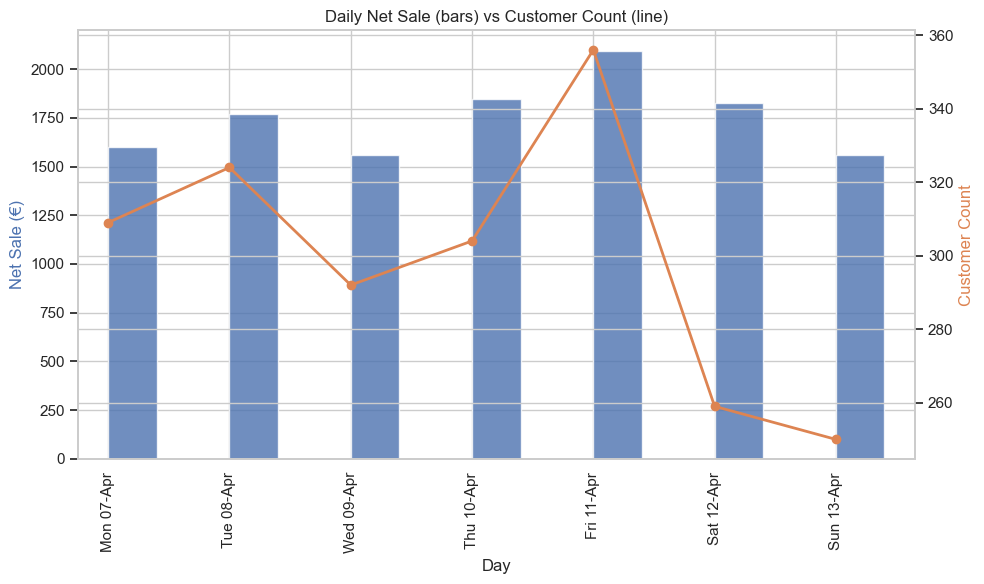

In [23]:
daily = long.groupby("Date")[["Customer Count", "Net Sale"]].sum() #reshaping the data using 'groupby'
daily.index = [d.strftime("%a %d-%b") for d in daily.index] #formatting each column label

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

daily["Net Sale"].plot(kind="bar", ax=ax1, color="#4C72B0", alpha=0.8, position=0, width=0.4)
daily["Customer Count"].plot(kind="line", ax=ax2, color="#DD8452", marker="o", linewidth=2)

ax1.set_ylabel("Net Sale (€)", color="#4C72B0")
ax2.set_ylabel("Customer Count", color="#DD8452")
ax1.set_xlabel("Day")
plt.title("Daily Net Sale (bars) vs Customer Count (line)")
fig.tight_layout()
plt.show()

### 7.3 Average spend per customer, by hour

Reveals hours that are quiet but high-value, or busy but low-value — useful for staffing and planning. 

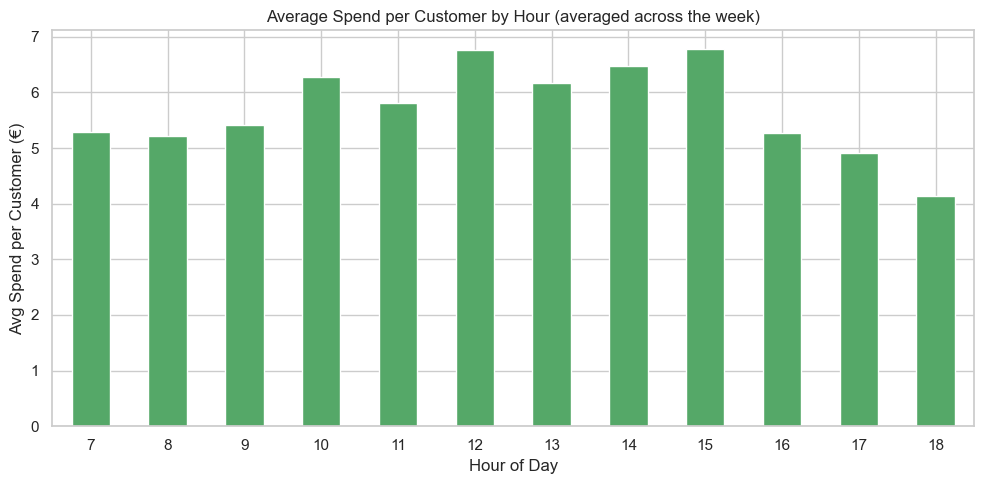

In [25]:
hourly_avg = long.groupby("Hour")["Avg Spend per Customer"].mean() #reshaping the data using 'groupby' to get the average spend per customer by hour.

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="bar", color="#55A868")
plt.title("Average Spend per Customer by Hour (averaged across the week)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Spend per Customer (€)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 8. Summary of findings

- **Peak trading window**: 10am, 11 and 12:00pm
- **Best/worst day**: Friday was busy with highest sales and customer count, whereas Saturday has a higher spending with less customers. Lowest total sales of the week was Wednesday and Sunday (Sunday with lowest customers count) 
- **Spend-per-customer pattern**: Average spend usually high at 10:00 am and early hours in the afternoon from 12:00 - 15:00 pm 